# Customer Value Segmentation

**Portfolio project — synthetic data.** This notebook walks through an end-to-end unsupervised
customer segmentation analysis for a fictional UK subscription/retail business: data generation,
cleaning, RFM & behavioural feature engineering, clustering model selection, segment profiling,
statistical validation, and business strategy.

All data is synthetically generated (`src/data_generation.py`) and does not represent a real
company. The full pipeline (identical logic to this notebook) can also be run non-interactively via
`src/run_pipeline.py` + `src/generate_reports.py`.


In [1]:
import sys
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 100})

import data_generation as dg
import preprocessing as pp
import feature_engineering as fe
import clustering as cl
import evaluation as ev

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)


## 1. Business Scenario & Synthetic Data Generation

The company has 10,000+ customers but treats them as one group. We generate a synthetic transaction
history (customers + 12+ months of orders) with **realistic data-quality issues** and **overlapping,
noisy behavioural archetypes** — deliberately avoiding obviously-separated clusters, so the
segmentation that follows requires genuine analysis rather than reading off a pre-baked label.


In [2]:
customers_raw, transactions_raw = dg.main(output_dir='../data/raw')
print(customers_raw.shape, transactions_raw.shape)
customers_raw.head()


Generating customer master table...
Generating transaction log (this may take a moment)...


Injecting realistic data-quality issues...


Saved 10,532 customer rows -> ../data/raw/customers.csv
Saved 112,055 transaction rows -> ../data/raw/transactions.csv
(10532, 9) (112055, 6)


,customer_id,signup_date,region,acquisition_channel,age,newsletter_opt_in,loyalty_member,support_tickets_12m,avg_satisfaction_score
0,100000,2023-12-09,Wales,Referral,38.0,True,True,1,3.2
1,100001,2023-11-14,South West,Paid Search,37.0,True,False,0,4.4
2,100002,2023-12-03,East of England,Affiliate,39.0,True,False,5,3.5
3,100003,2025-01-24,West Midlands,Organic,NaN,False,False,1,NaN
4,100004,2023-02-09,West Midlands,Email,47.0,True,False,0,NaN


In [3]:
transactions_raw.head()


,customer_id,order_date,order_value,product_category,is_return,channel
0,100000,2024-03-13,61.54,Electronics,False,Web
1,100000,2024-03-03,57.88,Groceries,False,Web
2,100000,2024-03-04,70.96,Pet Supplies,False,Web
3,100000,2024-03-24,15.02,Sports & Outdoors,False,Web
4,100000,2024-05-02,31.86,Toys & Kids,False,Mobile App


## 2. Data Validation & Cleaning

We check for duplicates, missing values, invalid values (negative order values), and outliers, and
apply **documented, justified** treatment decisions for each (see `reports/quality_control_report.md`
for the full rationale — e.g. why outliers are winsorised rather than dropped).


In [4]:
customers_clean, transactions_clean, clean_log = pp.validate_and_clean(customers_raw, transactions_raw)
for k, v in clean_log.items():
    print(f"{k}: {v}")


duplicate_customer_rows_removed: 32
duplicate_transaction_rows_removed: 889
duplicate_customer_ids_collapsed: 0
missing_pct_customers: {'region': 2.0, 'age': 4.0, 'avg_satisfaction_score': 12.0}
missing_pct_transactions: {'order_value': 0.5}
transaction_rows_dropped_missing_value: 556
negative_order_values_corrected: 8
invalid_age_rows_removed: 0
order_value_iqr_bounds: {'lower': 0.0, 'upper': 193.14}
extreme_order_value_outliers_flagged: 1526
orphan_transactions_removed: 0
final_customer_count: 10500
final_transaction_count: 110610


## 3. Feature Engineering: RFM + Behavioural Features

We aggregate transactions to customer level and construct **Recency, Frequency, Monetary (RFM)**
variables, plus tenure, category breadth, return rate, and tenure-normalised activity measures.
Field definitions: `reports/data_dictionary.md`.


In [5]:
features = fe.build_customer_features(customers_clean, transactions_clean, snapshot_date='2025-01-31')
print(features.shape)
features[['customer_id','recency_days','frequency','monetary_total','avg_order_value','tenure_months']].describe()


(10500, 31)


,customer_id,recency_days,frequency,monetary_total,avg_order_value,tenure_months
count,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000
mean,105249.500000,67.545905,10.534286,587.946995,40.459644,12.442924
std,3031.233247,93.042528,10.073644,714.413664,23.634065,7.888292
min,100000.000000,3.000000,0.000000,0.000000,0.000000,0.200000
25%,102624.750000,12.000000,2.000000,68.460000,24.143833,6.200000
50%,105249.500000,34.000000,7.000000,268.290000,40.805641,12.300000
75%,107874.250000,75.000000,16.000000,816.927500,59.461986,18.200000
max,110499.000000,865.000000,46.000000,3573.210000,193.140000,38.700000


## 4. Exploratory Analysis

### 4.1 RFM Distributions
RFM variables are typically right-skewed in retail data — a small number of very active/high-spend
customers create a long tail. We check this explicitly rather than assuming it.


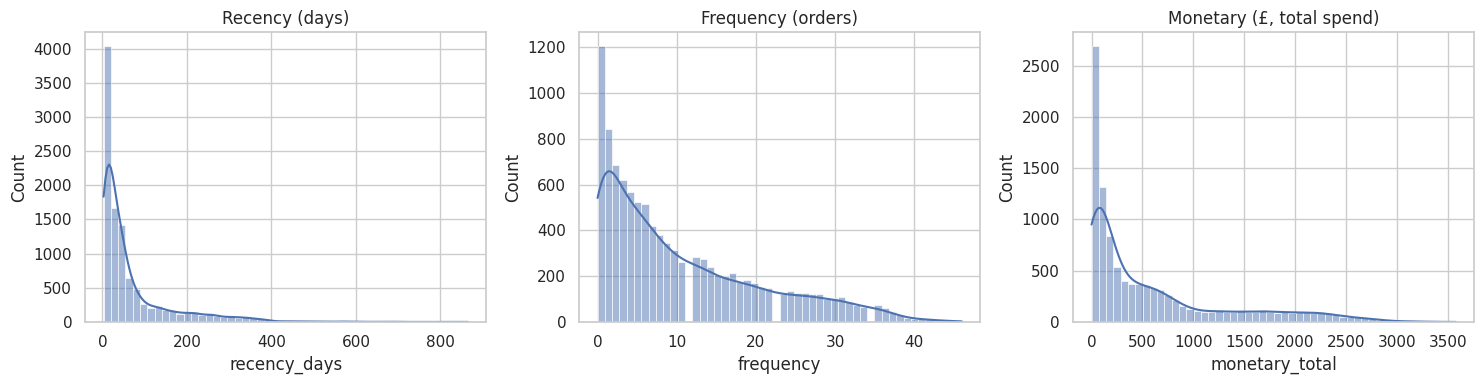

Skewness:
recency_days       2.69
frequency          1.02
monetary_total     1.45
avg_order_value    0.17
tenure_months      0.19
dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['recency_days','frequency','monetary_total'],
                          ['Recency (days)','Frequency (orders)','Monetary (£, total spend)']):
    sns.histplot(features[col], bins=50, ax=ax, kde=True)
    ax.set_title(title)
plt.tight_layout()
plt.show()

print('Skewness:')
print(features[['recency_days','frequency','monetary_total','avg_order_value','tenure_months']].skew().round(2))


### 4.2 Correlation & Redundancy

We check for highly correlated (redundant) features before clustering. Correlated pairs are noted;
some are kept anyway if they carry *distinct business meaning* (e.g. frequency vs monetary value —
a customer who buys often at low value differs strategically from one who buys rarely at high
value), with the reasoning made explicit rather than dropping features mechanically.


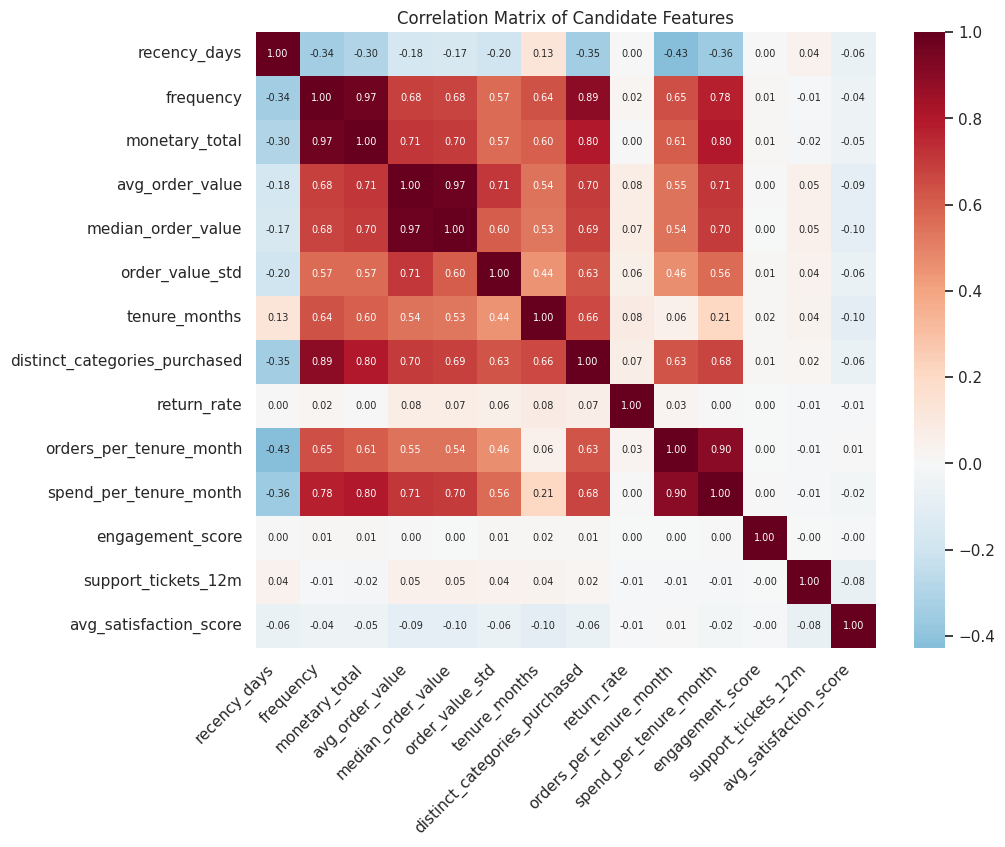

Redundant pairs (|r| > 0.8): [('frequency', 'monetary_total', 0.97), ('frequency', 'distinct_categories_purchased', 0.888), ('monetary_total', 'distinct_categories_purchased', 0.803), ('avg_order_value', 'median_order_value', 0.974), ('orders_per_tenure_month', 'spend_per_tenure_month', 0.904)]


In [7]:
corr_features = ['recency_days','frequency','monetary_total','avg_order_value','median_order_value',
                  'order_value_std','tenure_months','distinct_categories_purchased','return_rate',
                  'orders_per_tenure_month','spend_per_tenure_month','engagement_score',
                  'support_tickets_12m','avg_satisfaction_score']
corr = features[corr_features].corr()

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, annot_kws={'size':7})
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Matrix of Candidate Features')
plt.show()

redundant = [(a,b,round(float(corr.loc[a,b]),3)) for i,a in enumerate(corr_features)
             for b in corr_features[i+1:] if abs(corr.loc[a,b]) > 0.8]
print('Redundant pairs (|r| > 0.8):', redundant)


## 5. Preparing Features for Clustering

Skewed features are power-transformed (**Yeo-Johnson**, which — unlike log1p — handles zero and
negative values while correcting skew), then **all features are standardised** to zero mean / unit
variance. Standardisation matters because distance-based clustering (K-Means, Ward-linkage
hierarchical) is dominated by whichever feature has the largest raw scale — without it,
`monetary_total` (scale: £0–thousands) would swamp `return_rate` (scale: 0–1) regardless of true
business importance.


In [8]:
X, prep_meta = cl.prepare_clustering_matrix(features)
print('Clustering feature matrix:', X.shape)
print('\nFeatures used:', prep_meta['features'])
X.describe().round(2)


Clustering feature matrix: (10500, 10)

Features used: ['recency_days', 'frequency', 'monetary_total', 'avg_order_value', 'distinct_categories_purchased', 'return_rate', 'tenure_months', 'orders_per_tenure_month', 'spend_per_tenure_month', 'engagement_score']


,recency_days,frequency,monetary_total,avg_order_value,distinct_categories_purchased,return_rate,tenure_months,orders_per_tenure_month,spend_per_tenure_month,engagement_score
count,10500.00,10500.00,10500.00,10500.00,10500.00,10500.00,10500.00,10500.00,10500.00,10500.00
mean,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.93,-1.66,-1.79,-1.94,-1.53,-0.56,-1.55,-1.62,-1.72,-1.34
25%,-0.78,-0.87,-0.66,-0.59,-0.93,-0.56,-0.79,-0.77,-0.74,-1.34
50%,0.09,-0.00,0.01,0.10,-0.04,-0.56,-0.02,0.07,0.11,0.10
75%,0.72,0.79,0.73,0.80,0.86,0.27,0.73,0.73,0.76,0.10
max,2.40,2.06,2.05,4.89,1.46,7.17,3.33,3.69,3.18,1.54


## 6. Cluster Count Selection: Elbow, Silhouette & Stability

We compare **K-Means** and **hierarchical (Ward-linkage) clustering** across a range of k, using the
elbow method (inertia), mean silhouette score, Davies-Bouldin index, and **bootstrap stability**
(mean Adjusted Rand Index across 10 resampled refits — a high value means the partition is
reproducible, not an artefact of one particular sample).


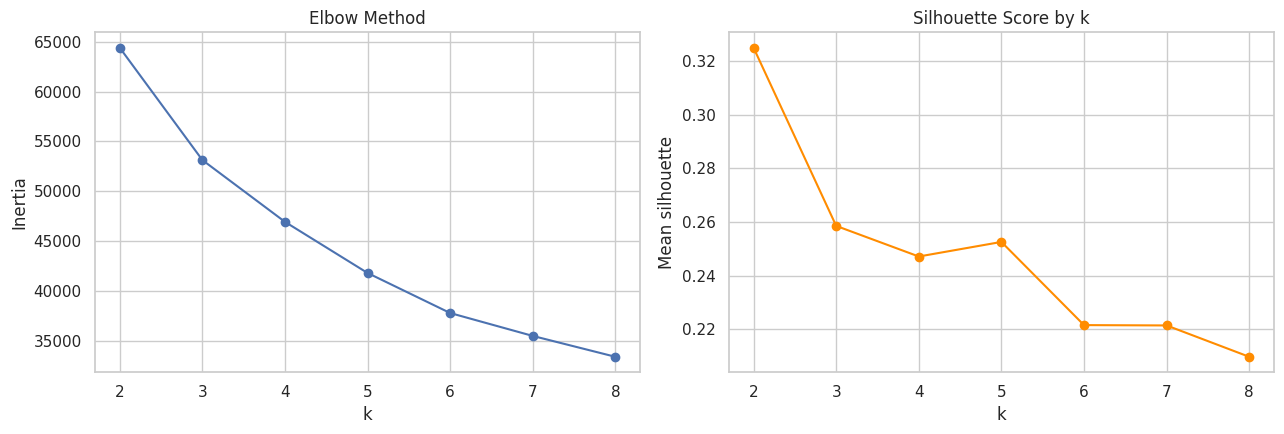

Inertias: {2: 64393.8, 3: 53128.1, 4: 46927.7, 5: 41797.3, 6: 37779.5, 7: 35482.5, 8: 33389.4}
Silhouettes: {2: 0.3251, 3: 0.2585, 4: 0.2471, 5: 0.2526, 6: 0.2215, 7: 0.2214, 8: 0.2097}


In [9]:
k_range = range(2, 9)
inertias = cl.elbow_analysis(X, k_range)
silhouettes = cl.silhouette_analysis(X, k_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(list(silhouettes.keys()), list(silhouettes.values()), marker='o', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Mean silhouette'); axes[1].set_title('Silhouette Score by k')
plt.tight_layout(); plt.show()

print('Inertias:', {k: round(v,1) for k,v in inertias.items()})
print('Silhouettes:', {k: round(v,4) for k,v in silhouettes.items()})


In [10]:
model_selection = []
for k in [2, 3, 4, 5]:
    stability = cl.stability_analysis(X, k)
    comparison, km_labels, agg_labels = cl.compare_algorithms(X, k)
    model_selection.append({
        'k': k,
        'kmeans_silhouette': round(comparison['kmeans']['silhouette'], 3),
        'hierarchical_silhouette': round(comparison['hierarchical']['silhouette'], 3),
        'kmeans_davies_bouldin': round(comparison['kmeans']['davies_bouldin'], 3),
        'kmeans_vs_hier_agreement_ari': round(comparison['agreement_ari'], 3),
        'bootstrap_stability_ari': round(stability['mean_ari'], 3),
    })
pd.DataFrame(model_selection)


,k,kmeans_silhouette,hierarchical_silhouette,kmeans_davies_bouldin,kmeans_vs_hier_agreement_ari,bootstrap_stability_ari
0,2,0.325,0.288,1.188,0.615,0.987
1,3,0.259,0.248,1.336,0.650,0.995
2,4,0.247,0.151,1.523,0.422,0.978
3,5,0.253,0.161,1.384,0.420,0.977


### Why k = 4, not the k with the highest silhouette score

**k = 2 has the highest raw silhouette score** — but inspecting that partition shows it almost
perfectly separates customers into "has purchased" vs "has never purchased." That's real structure,
but far too coarse to drive differentiated retention/marketing strategy on its own.

**k = 3** offers a slightly better silhouette/stability trade-off than k = 4, but it collapses two
behaviourally and strategically distinct groups — *newly acquired, low-activity customers* and
*long-tenured customers who have gone quiet* — into a single middle cluster. Those two groups need
opposite interventions (onboarding vs. win-back), so merging them would actively mislead strategy.

**k = 4** is the smallest k that cleanly separates those groups while keeping bootstrap stability
high and silhouette respectable. Beyond k = 4, the elbow curve flattens and additional clusters
mostly subdivide existing groups without new business-relevant distinctions.

We proceed with **k = 4**, fit with K-Means (chosen over hierarchical clustering at this k for its
higher silhouette score, lower Davies-Bouldin index, and better scalability).


In [11]:
FINAL_K = 4
km_final, km_labels = cl.fit_kmeans(X, FINAL_K)
agg_final, agg_labels = cl.fit_hierarchical(X, FINAL_K)

features['segment'] = km_labels
features['segment_hierarchical'] = agg_labels

final_comparison, _, _ = cl.compare_algorithms(X, FINAL_K)
print('Final K-Means silhouette:', round(final_comparison['kmeans']['silhouette'], 4))
print('Final Hierarchical silhouette:', round(final_comparison['hierarchical']['silhouette'], 4))
print('K-Means vs Hierarchical agreement (ARI):', round(final_comparison['agreement_ari'], 4))
print('Bootstrap stability (ARI):', round(cl.stability_analysis(X, FINAL_K)['mean_ari'], 4))


Final K-Means silhouette: 0.2471
Final Hierarchical silhouette: 0.1507
K-Means vs Hierarchical agreement (ARI): 0.4216


Bootstrap stability (ARI): 0.9778


## 7. Dimensionality Reduction (PCA) for Visualisation

PCA is used **only to visualise** the already-fitted cluster solution in 2D — clustering itself was
performed on the full standardised feature space, not the PCA projection. The components are linear
combinations of every input feature, so we avoid over-interpreting PC1/PC2 as clean business
concepts like "value" or "engagement."


In [12]:
pca, components, explained, loadings = cl.run_pca(X, n_components=2)
features['pca_1'] = components[:, 0]
features['pca_2'] = components[:, 1]
print(f"Variance explained: PC1={explained[0]*100:.1f}%, PC2={explained[1]*100:.1f}% "
      f"(combined {sum(explained[:2])*100:.1f}%)")
loadings.round(3)


Variance explained: PC1=56.2%, PC2=13.3% (combined 69.5%)


,PC1,PC2
recency_days,-0.150,0.629
frequency,0.409,0.080
monetary_total,0.417,0.093
avg_order_value,0.364,0.115
distinct_categories_purchased,0.398,0.084
return_rate,0.042,0.226
tenure_months,0.257,0.582
orders_per_tenure_month,0.350,-0.363
spend_per_tenure_month,0.393,-0.215
engagement_score,0.003,0.040


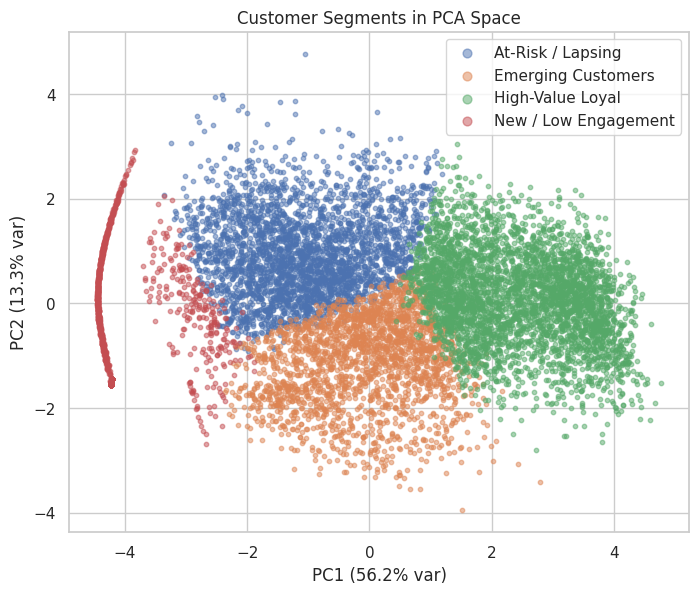

In [13]:
profile_preview = ev.profile_segments(features, 'segment')
names_preview = ev.name_segments(profile_preview)
seg_name_map = dict(zip(names_preview['segment'], names_preview['segment_name']))
features['segment_name'] = features['segment'].map(seg_name_map)

fig, ax = plt.subplots(figsize=(8,6.5))
for seg_name, sub in features.groupby('segment_name'):
    ax.scatter(sub['pca_1'], sub['pca_2'], s=10, alpha=0.5, label=seg_name)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax.set_title('Customer Segments in PCA Space')
ax.legend(markerscale=2)
plt.show()


## 8. Segment Profiling & Business-Friendly Naming

Segment names are **derived programmatically** from each segment's rank on value (monetary +
frequency), recency, and tenure relative to the *other segments in this run* — not hard-coded — so
they adapt automatically if re-clustering changes segment composition.


In [14]:
profile = ev.profile_segments(features, 'segment')
names = ev.name_segments(profile)
profile = profile.merge(names, on='segment')
profile = profile.sort_values('pct_of_total_monetary', ascending=False).reset_index(drop=True)
profile[['segment_name','customer_count','pct_of_customers','pct_of_total_monetary',
         'avg_recency_days','avg_frequency','avg_monetary_total','avg_tenure_months']]


,segment_name,customer_count,pct_of_customers,pct_of_total_monetary,avg_recency_days,avg_frequency,avg_monetary_total,avg_tenure_months
0,High-Value Loyal,3816,36.34,83.30,29.90,21.75,1347.58,18.50
1,Emerging Customers,2228,21.22,8.40,27.01,5.89,232.86,5.74
2,At-Risk / Lapsing,2992,28.50,8.23,127.36,4.75,169.77,13.91
3,New / Low Engagement,1464,13.94,0.07,105.14,0.21,2.95,3.86


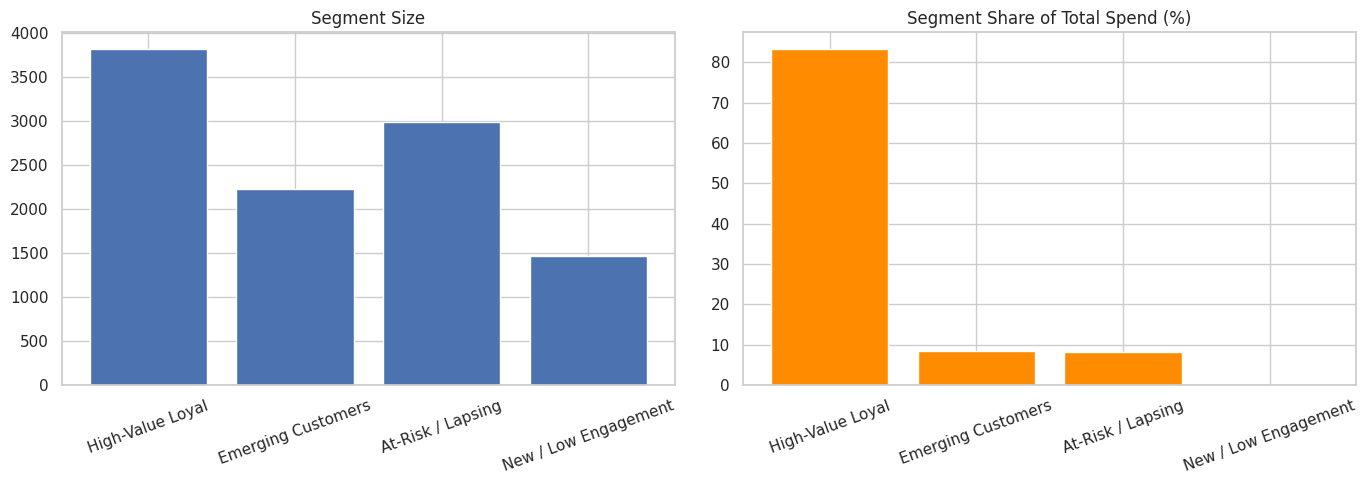

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].bar(profile['segment_name'], profile['customer_count'])
axes[0].set_title('Segment Size'); axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(profile['segment_name'], profile['pct_of_total_monetary'], color='darkorange')
axes[1].set_title('Segment Share of Total Spend (%)'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


## 9. Statistical Validation

We use the **Kruskal-Wallis H-test** (non-parametric — appropriate given the non-normal, skewed RFM
distributions) to test whether each metric genuinely differs across segments, report **effect size
(epsilon-squared)** to judge practical (not just statistical) significance, and apply
**Benjamini-Hochberg FDR correction** since many metrics are tested simultaneously.


In [16]:
stats_results = ev.statistical_validation(features, 'segment')
stats_results[['metric','h_statistic','p_value','p_value_fdr_corrected',
               'significant_after_correction','effect_size_epsilon_sq','effect_size_label']]


,metric,h_statistic,p_value,p_value_fdr_corrected,significant_after_correction,effect_size_epsilon_sq,effect_size_label
0,monetary_total,8622.381932,0.000000e+00,0.000000e+00,True,0.821206,large
1,frequency,8550.220510,0.000000e+00,0.000000e+00,True,0.814331,large
2,distinct_categories_purchased,8336.203995,0.000000e+00,0.000000e+00,True,0.793941,large
3,spend_per_tenure_month,8075.872511,0.000000e+00,0.000000e+00,True,0.769138,large
4,orders_per_tenure_month,7536.478331,0.000000e+00,0.000000e+00,True,0.717748,large
5,avg_order_value,6360.651750,0.000000e+00,0.000000e+00,True,0.605721,large
6,median_order_value,6277.856843,0.000000e+00,0.000000e+00,True,0.597833,large
7,tenure_months,5935.996401,0.000000e+00,0.000000e+00,True,0.565263,large
8,recency_days,3268.007968,0.000000e+00,0.000000e+00,True,0.311072,large
9,return_rate,1820.961508,0.000000e+00,0.000000e+00,True,0.173205,large


Large effect sizes (e.g. `monetary_total`, `frequency`, `tenure_months`) confirm the segments
differ substantially in the variables the business cares about most. A few metrics
(`avg_satisfaction_score`, `engagement_score`, `support_tickets_12m`) show negligible effect sizes —
this is reported honestly rather than selectively omitted, since these variables were not part of the
clustering feature set and should not be assumed to distinguish segments.


## 10. Business Strategy Summary

Each segment's strategy is grounded directly in its computed profile (see
`reports/business_strategy.md` for full detail per segment):


In [17]:
strategy_map = {
    'High-Value Loyal': 'Retain & reward — loyalty perks, premium tiers, proactive relationship management.',
    'At-Risk High Value': 'Targeted win-back — personal outreach and service recovery.',
    'At-Risk / Lapsing': 'Re-engagement campaigns — win-back offers and satisfaction check-ins.',
    'Emerging Customers': 'Growth & cross-sell — category expansion, loyalty enrolment.',
    'New / Low Engagement': 'Onboarding — welcome journeys, first-purchase incentives.',
    'Dormant Long-Tenure': 'Reactivate or gracefully sunset — relevance-testing, then suppress spend.',
    'Steady Mid-Value': 'Nurture — consistent engagement, incremental upsell.',
}
for _, row in profile.iterrows():
    base = row['segment_name'].split(' (Segment')[0]
    print(f"{row['segment_name']} ({row['customer_count']:,} customers, "
          f"{row['pct_of_total_monetary']:.1f}% of spend): {strategy_map.get(base, 'Monitor and tailor.')}")


High-Value Loyal (3,816 customers, 83.3% of spend): Retain & reward — loyalty perks, premium tiers, proactive relationship management.
Emerging Customers (2,228 customers, 8.4% of spend): Growth & cross-sell — category expansion, loyalty enrolment.
At-Risk / Lapsing (2,992 customers, 8.2% of spend): Re-engagement campaigns — win-back offers and satisfaction check-ins.
New / Low Engagement (1,464 customers, 0.1% of spend): Onboarding — welcome journeys, first-purchase incentives.


## 11. Executive Summary

- **Segments identified:** see table above.
- **Highest-value segment** drives the majority of total spend from a minority of customers —
  retention investment should be prioritised accordingly.
- **At-risk segment(s)** represent meaningful revenue that will be lost without timely, targeted
  intervention.
- Full executive dashboard: `visualisations/10_executive_dashboard.png`.
- Full written reports: `reports/` (data dictionary, segmentation report, statistical report,
  business strategy, quality control report, portfolio case study).

*This notebook mirrors `src/run_pipeline.py`; run that script (followed by `src/generate_reports.py`)
to regenerate all saved visualisations and markdown reports non-interactively.*
